异常（Exception）是程序运行时发生的错误，Python 提供了完善的异常处理机制，既能捕获错误避免程序崩溃，也能自定义异常满足业务需求。
# 一、核心概念
- 异常对象：Python 中所有异常都是 BaseException 的子类（常用的是 Exception 子类），错误发生时会生成一个异常对象。
- 异常触发：
    1. 自动触发：比如除数为0、访问不存在的列表索引。
    2. 手动触发：通过raise关键字主动抛出。
- 异常处理：通过try-except等语句捕获并处理异常，避免程序直接终止。
# 二、基础异常处理语法
1. 最基础的try-except

In [ ]:
"""
# 语法结构
try:
    # 可能触发异常的代码块
    risky_code
except ExceptionType:
    # 捕获指定类型的异常后执行的代码
    handle_code
"""

In [1]:
try:
    a = 10 / 0  # 触发 ZeroDivisionError
except ZeroDivisionError:
    print("错误：除数不能为 0")

# 输出：错误：除数不能为 0

错误：除数不能为 0


2. 捕获多个异常
- 方式1:多个except子句

In [2]:
try:
    num = int(input("请输入数字："))  # 输入非数字触发 ValueError
    result = 10 / num  # 输入 0 触发 ZeroDivisionError
except ValueError:
    print("错误：输入的不是有效数字")
except ZeroDivisionError:
    print("错误：除数不能为 0")

# 测试 1：输入 "abc" → 输出 "错误：输入的不是有效数字"
# 测试 2：输入 0 → 输出 "错误：除数不能为 0"

错误：输入的不是有效数字


- 方式2:一个except捕获多个异常（元组形式）

In [ ]:
try:
    num = int(input("请输入数字："))
    result = 10 / num
except (ValueError, ZeroDivisionError) as e:  # as e 捕获异常对象，查看详细信息
    print(f"发生错误：{e}")  # e 是异常对象，打印错误描述

# 测试：输入 0 → 输出 "发生错误：division by zero"

3. 万能捕获（捕获所有异常）

In [3]:
try:
    num = int(input("请输入数字："))
    result = 10 / num
except Exception as e:  # Exception 是所有非系统退出异常的父类
    print(f"通用错误：{type(e).__name__} - {e}")

# 测试：输入 "abc" → 输出 "通用错误：ValueError - invalid literal for int() with base 10: 'abc'"

通用错误：ZeroDivisionError - division by zero


4. else子句：无异常时执行。else仅在try块无异常时执行，分离“正常逻辑”和“异常处理逻辑”，代码更清晰

In [5]:
try:
    num = int(input("请输入数字："))
    result = 10 / num
except (ValueError, ZeroDivisionError) as e:
    print(f"错误：{e}")
else:
    print(f"计算结果：{result}")  # 仅无异常时执行

# 测试：输入 2 → 输出 "计算结果：5.0"

错误：division by zero


5. finally子句：无论是否异常都执行。常用于释放资源（关闭文件、数据库连接），即使try中用了return，finally也会执行。

In [8]:
try:
    f = open("./0-文件/test.txt", "r")
    content = f.read()
    print(content)
except FileNotFoundError:
    print("错误：文件不存在")
finally:
    if 'f' in locals():  # 确保 f 已定义
        f.close()
        print("文件已关闭")

# 结果：无论文件是否存在，都会打印 "文件已关闭"

错误：文件不存在
文件已关闭


# 三、手动抛出异常（raise）
1. 基础用法：通过raise主动抛出异常，适用于“业务逻辑错误”（如输入值超出范围）。

In [9]:
def check_age(age):
    if age < 0 or age > 150:
        # 抛出 ValueError，可自定义错误信息
        raise ValueError(f"年龄 {age} 不符合逻辑（0-150）")
    print(f"年龄有效：{age}")

# 调用测试
try:
    check_age(200)
except ValueError as e:
    print(f"错误：{e}")  # 输出 "错误：年龄 200 不符合逻辑（0-150）"

错误：年龄 200 不符合逻辑（0-150）


2. 重新抛出异常：捕获异常后，若无法处理，可通过raise重新抛出（保留原始异常栈）

In [10]:
def func():
    try:
        10 / 0
    except ZeroDivisionError as e:
        print("记录错误日志：", e)
        raise  # 重新抛出，不修改原始异常

try:
    func()
except ZeroDivisionError as e:
    print(f"最终捕获：{e}")

# 输出：
# 记录错误日志：division by zero
# 最终捕获：division by zero

记录错误日志： division by zero
最终捕获：division by zero


# 四、自定义异常
当内置异常无法满足业务需求时，可自定义异常类（必须继承Exception）。
1. 示例：自定义业务异常

In [11]:
# 自定义异常类（继承 Exception）
class LoginError(Exception):
    """登录异常（自定义）"""
    # 可自定义初始化方法，添加额外属性
    def __init__(self, code, message):
        self.code = code  # 错误码
        self.message = message  # 错误信息
    # 自定义打印格式
    def __str__(self):
        return f"[{self.code}] {self.message}"

# 模拟登录函数
def login(username, password):
    if username != "admin":
        raise LoginError(1001, "用户名不存在")
    if password != "123456":
        raise LoginError(1002, "密码错误")
    print("登录成功")

# 调用测试
try:
    login("admin", "123")
except LoginError as e:
    print(f"登录失败：{e}")  # 输出 "登录失败：[1002] 密码错误"

登录失败：[1002] 密码错误


# 五、常见内置异常
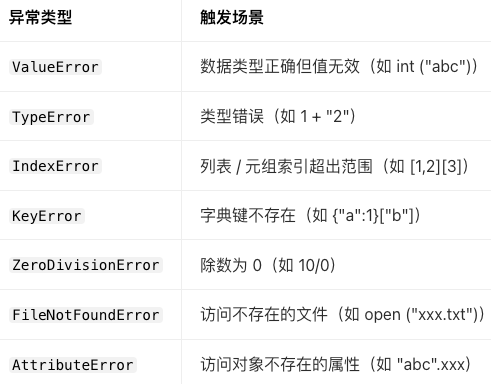

# 六、关键细节与最佳实现
1. 异常捕获的优先级
- 子类异常需放在父类异常前面，否则父类会“覆盖”子类，导致子类异常无法被精准捕获。

In [12]:
# 错误示例：Exception 是 ValueError 的父类，放在前面会捕获所有异常
try:
    int("abc")
except Exception:
    print("通用错误")
except ValueError:
    print("值错误")  # 永远不会执行

# 正确示例：子类在前
try:
    int("abc")
except ValueError:
    print("值错误")  # 执行
except Exception:
    print("通用错误")

通用错误
值错误


2. 避免“空except”
- 空except：会捕获所有异常（包括SystemExit、KeyboardInterrupt），导致程序无法被Ctrl+C 终止，且隐藏未知错误。

In [13]:
# 错误示例：空 except
try:
    10 / 0
except:  # 不推荐
    pass  # 吞掉异常，无法定位问题

# 正确示例：指定具体异常
try:
    10 / 0
except ZeroDivisionError:
    print("除数为 0")

除数为 0


3. 异常追踪
- 使用traceback模块可打印完整的异常栈，方便调试。

In [14]:
import traceback

try:
    10 / 0
except ZeroDivisionError:
    # 打印完整异常栈
    traceback.print_exc()

# 输出包含错误行号、文件路径的详细栈信息，便于定位问题

Traceback (most recent call last):
  File "/var/folders/jz/w0r7pw612sbfpwfl_2fq3gxw0000gn/T/ipykernel_6853/3953179811.py", line 4, in <module>
    10 / 0
    ~~~^~~
ZeroDivisionError: division by zero


4. 异常与return的执行顺序
- finally会在return之前执行，若finally中有return，会覆盖try/except中的return。

In [15]:
def func():
    try:
        10 / 0
    except ZeroDivisionError:
        return "异常返回"
    finally:
        return "finally 返回"  # 覆盖前面的 return

print(func())  # 输出 "finally 返回"

finally 返回
